In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv.zip')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'netflix_titles.csv'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv.zip')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df.dropna(subset=['date_added', 'rating'], inplace=True)

# Remove duplicates
print("Duplicates removed:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Fix date column
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Split genres into individual rows
genres_series = df['listed_in'].str.split(', ').explode()

print("\nCleaning done! Final shape:", df.shape)

Duplicates removed: 0

Cleaning done! Final shape: (8793, 14)


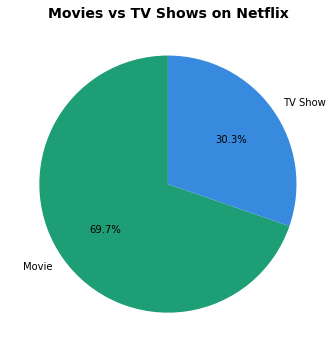

In [6]:
plt.figure(figsize=(6,5))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#1D9E75','#378ADD'], startangle=90)
plt.title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_type_split.png', dpi=150)
plt.show()

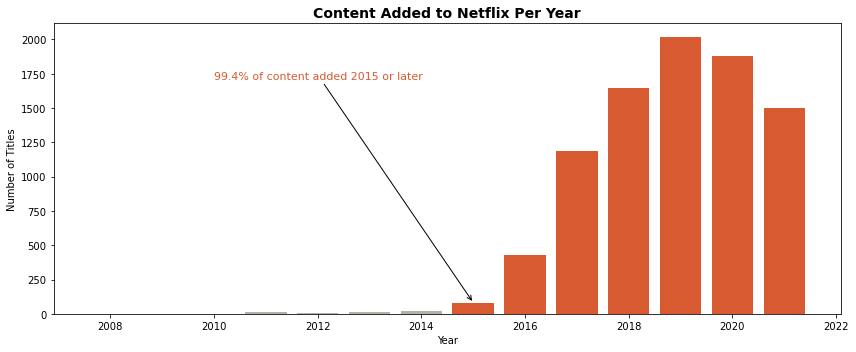

Content added after 2015: 99.4%


In [7]:
plt.figure(figsize=(12,5))
yearly = df['year_added'].value_counts().sort_index()
bars = plt.bar(yearly.index, yearly.values, color=['#D85A30' if y >= 2015 else '#B4B2A9' for y in yearly.index])
plt.title('Content Added to Netflix Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

after_2015 = df[df['year_added'] >= 2015].shape[0]
total = df.shape[0]
pct = round(after_2015 / total * 100, 1)
plt.annotate(f'{pct}% of content added 2015 or later',
             xy=(2015, yearly[2015]), xytext=(2010, yearly.max()*0.85),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, color='#D85A30')
plt.tight_layout()
plt.savefig('viz2_yearly_content.png', dpi=150)
plt.show()
print(f"Content added after 2015: {pct}%")

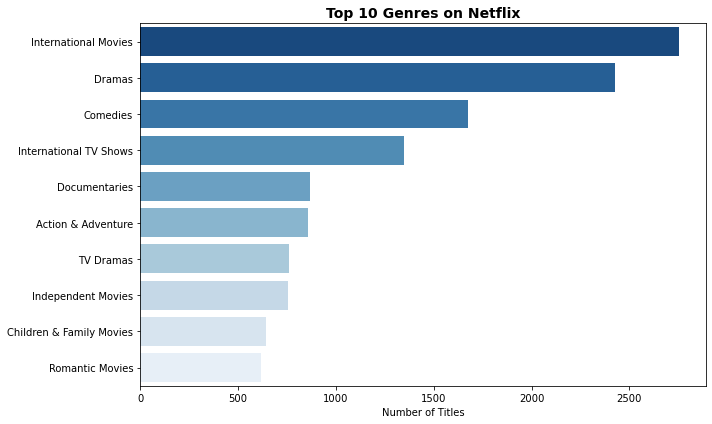

Total unique genres: 42


In [8]:
plt.figure(figsize=(10,6))
top_genres = genres_series.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('viz3_top_genres.png', dpi=150)
plt.show()
print(f"Total unique genres: {genres_series.nunique()}")

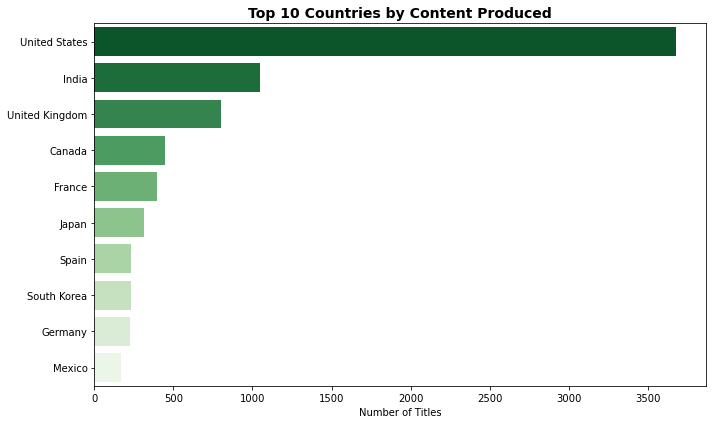

In [9]:
plt.figure(figsize=(10,6))
top_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r')
plt.title('Top 10 Countries by Content Produced', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('viz4_top_countries.png', dpi=150)
plt.show()

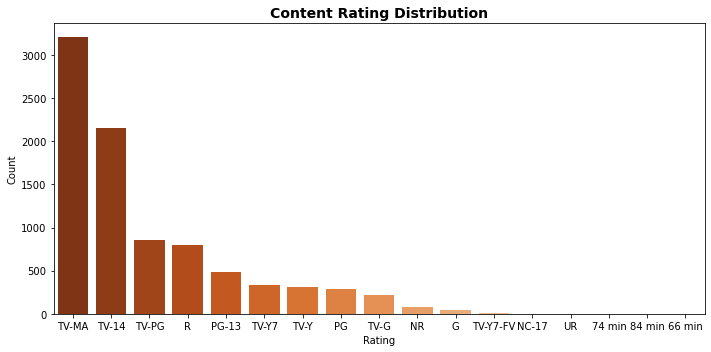

In [10]:
plt.figure(figsize=(10,5))
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Oranges_r')
plt.title('Content Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('viz5_ratings.png', dpi=150)
plt.show()

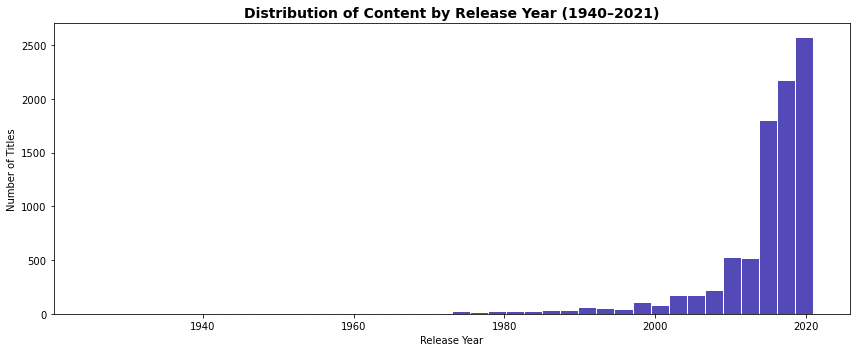

Earliest release year: 1925
Latest release year: 2021


In [11]:
plt.figure(figsize=(12,5))
plt.hist(df['release_year'], bins=40, color='#534AB7', edgecolor='white')
plt.title('Distribution of Content by Release Year (1940–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('viz6_release_year.png', dpi=150)
plt.show()
print("Earliest release year:", df['release_year'].min())
print("Latest release year:", df['release_year'].max())

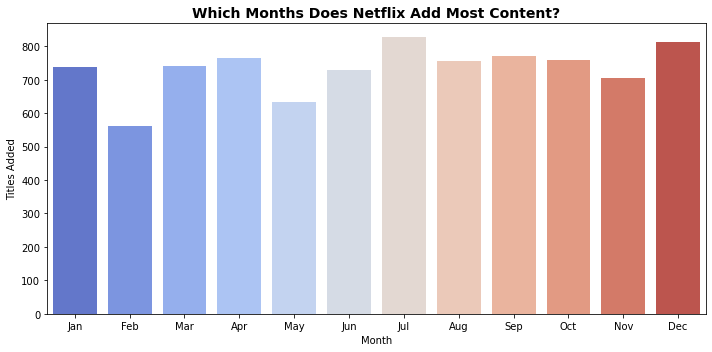

In [12]:
plt.figure(figsize=(10,5))
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df['month_added'].value_counts().sort_index()
monthly.index = [month_map[m] for m in monthly.index]
sns.barplot(x=monthly.index, y=monthly.values, palette='coolwarm')
plt.title('Which Months Does Netflix Add Most Content?', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.tight_layout()
plt.savefig('viz7_monthly.png', dpi=150)
plt.show()

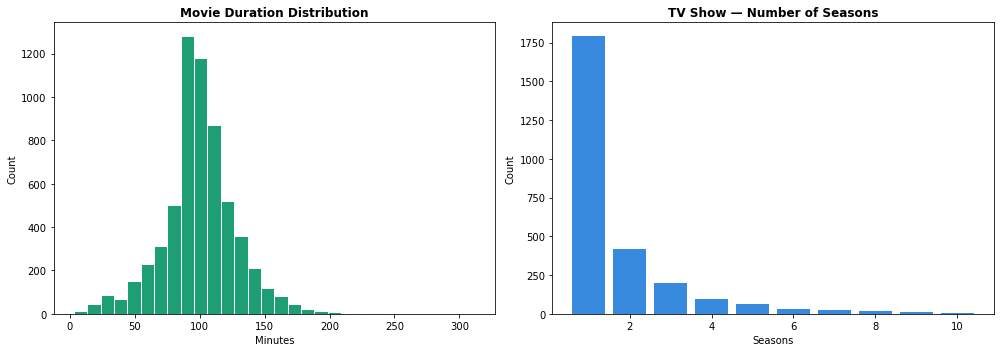

Average movie length: 100 minutes


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Movie durations
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.replace(' min','').astype(float)
axes[0].hist(movies['minutes'], bins=30, color='#1D9E75', edgecolor='white')
axes[0].set_title('Movie Duration Distribution', fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

# TV show seasons
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = shows['duration'].str.replace(' Season.*','', regex=True).astype(float)
season_counts = shows['seasons'].value_counts().sort_index().head(10)
axes[1].bar(season_counts.index.astype(int), season_counts.values, color='#378ADD')
axes[1].set_title('TV Show — Number of Seasons', fontweight='bold')
axes[1].set_xlabel('Seasons')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('viz8_9_duration_seasons.png', dpi=150)
plt.show()
print(f"Average movie length: {round(movies['minutes'].mean())} minutes")

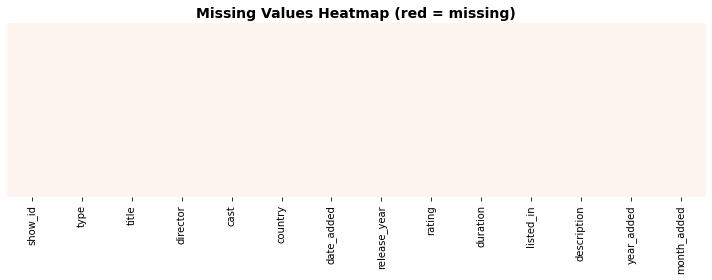

In [14]:
plt.figure(figsize=(10,4))
missing_df = df.isnull().astype(int)
sns.heatmap(missing_df, cbar=False, yticklabels=False, cmap='Reds')
plt.title('Missing Values Heatmap (red = missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz10_missing_heatmap.png', dpi=150)
plt.show()

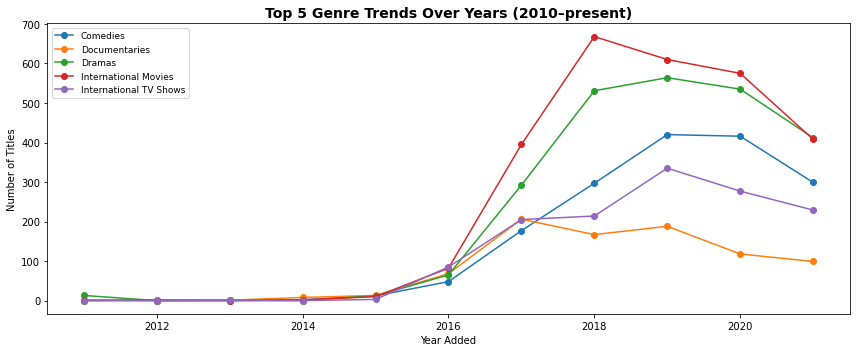

In [15]:
top5_genres = genres_series.value_counts().head(5).index.tolist()
genre_year = df.copy()
genre_year = genre_year.explode = genre_year.assign(genre=genre_year['listed_in'].str.split(', ')).explode('genre')
genre_year = genre_year[genre_year['genre'].isin(top5_genres)]
genre_pivot = genre_year.groupby(['year_added','genre']).size().unstack(fill_value=0)
genre_pivot = genre_pivot[genre_pivot.index >= 2010]

plt.figure(figsize=(12,5))
for col in genre_pivot.columns:
    plt.plot(genre_pivot.index, genre_pivot[col], marker='o', label=col)
plt.title('Top 5 Genre Trends Over Years (2010–present)', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('viz11_genre_trends.png', dpi=150)
plt.show()

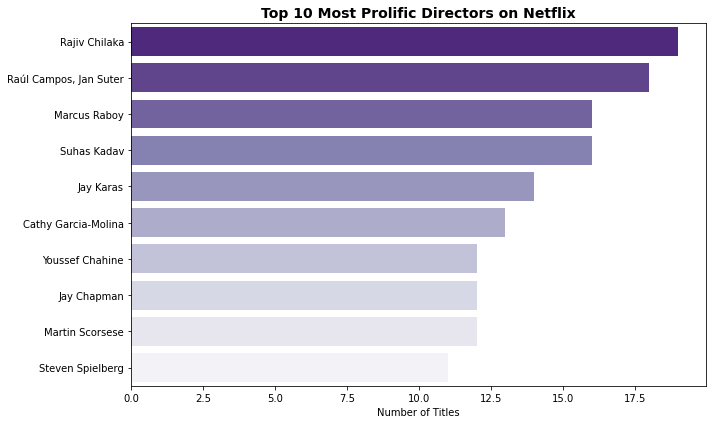

In [16]:
plt.figure(figsize=(10,6))
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='Purples_r')
plt.title('Top 10 Most Prolific Directors on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('viz12_directors.png', dpi=150)
plt.show()

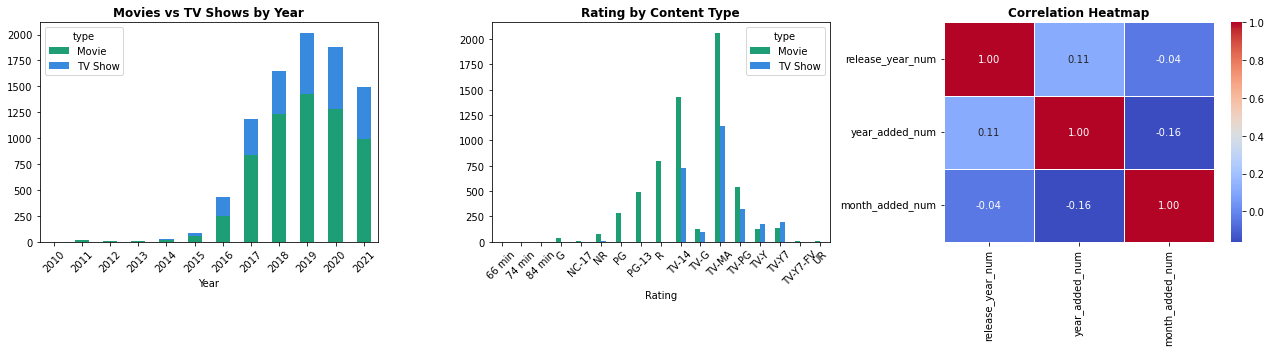

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Viz 13 — Movies vs TV by year
stacked = df.groupby(['year_added','type']).size().unstack(fill_value=0)
stacked = stacked[stacked.index >= 2010]
stacked.plot(kind='bar', stacked=True, ax=axes[0], color=['#1D9E75','#378ADD'])
axes[0].set_title('Movies vs TV Shows by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45)

# Viz 14 — Rating by content type
rating_type = df.groupby(['rating','type']).size().unstack(fill_value=0)
rating_type.plot(kind='bar', ax=axes[1], color=['#1D9E75','#378ADD'])
axes[1].set_title('Rating by Content Type', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].tick_params(axis='x', rotation=45)

# Viz 15 — Numeric correlation heatmap
df['release_year_num'] = df['release_year']
df['year_added_num'] = df['year_added']
df['month_added_num'] = df['month_added']
corr = df[['release_year_num','year_added_num','month_added_num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('viz13_14_15_final.png', dpi=150)
plt.show()

In [18]:
print("=" * 50)
print("PROJECT SUMMARY — USE THESE IN YOUR CV")
print("=" * 50)
print(f"Total titles analysed:     {df.shape[0]:,}")
print(f"Total columns:             {df.shape[1]}")
print(f"Unique genres:             {genres_series.nunique()}")
print(f"Year range:                {int(df['release_year'].min())}–{int(df['release_year'].max())}")
print(f"Content added after 2015:  {pct}%")
print(f"Avg movie duration:        {round(movies['minutes'].mean())} minutes")
print(f"Total visualisations:      15")
print("=" * 50)

PROJECT SUMMARY — USE THESE IN YOUR CV
Total titles analysed:     8,793
Total columns:             17
Unique genres:             42
Year range:                1925–2021
Content added after 2015:  99.4%
Avg movie duration:        100 minutes
Total visualisations:      15
